# Merge and Export Machine Learning Dataset
This notebook gathers all the pre-calculated features from the other scripts (OSM POIs, Land Use percentages, and Terrain Slope) and merges them into one single comprehensive `.csv` table that will be fed to the Machine Learning models.

## Note: Data Requirements

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datatsets

In [2]:
# Define file paths (UNCOMMENT AND ADJUST ONCE YOU HAVE EXPORTED THE DATA)

path_osm_roads = "data/osm_roads_noise_regre_with_tunnels.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points = "data/osm_points_features.csv"
path_osmlanduse = "data/osm_landuse_features.csv"

df_osm_roads = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points = pd.read_csv(path_osm_points)
df_osm_landuse = pd.read_csv(path_osmlanduse)

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,21638891_190971702_0,65,65,60,4,143.325492,1409.121451,146.914702,0.000000,151.351124,184.454492
1,26057125_26057304_0,70,65,60,3,1364.261619,108.740116,0.000000,138.887494,0.000000,137.141496
2,3601249498_3601250399_0,65,65,60,6,3061.643369,399.680682,0.000000,406.820267,62.359815,0.000000
3,26057050_168319807_0,70,65,60,2,1146.109648,0.000000,40.129104,0.000000,102.118862,130.263370
4,26057050_178518958_0,70,65,60,2,1039.406813,0.000000,81.607990,10.012431,0.000000,130.263370


In [4]:
df_momepy_roads.drop(['openness'], axis=1, inplace=True)  # Drop 'openness' to avoid duplication
df_momepy_roads.head()

,road_id,width,betweenness,closeness_global,closeness_400,straightness
0,21638845_885308258_0,43.025602,0.000896,0.000147,0.000006,0.798398
1,21638845_13175411896_0,26.114886,0.002015,0.000154,0.000011,0.812345
2,21638865_30343650_0,15.135908,0.000224,0.000161,0.000031,0.822206
3,21638867_1636238503_0,18.154330,0.002529,0.000168,0.000048,0.831058
4,21638867_1403082237_0,20.158620,0.002416,0.000168,0.000050,0.829978


In [5]:
df_osm_points.head()

,road_id,signals,transport,pois
0,21638845_885308258_0,0.105877,0.000000,0.070585
1,21638845_13175411896_0,0.022710,0.008111,0.014599
2,21638865_30343650_0,0.000000,0.000000,0.427369
3,21638867_1636238503_0,0.063558,0.000000,0.254232
4,21638867_1403082237_0,0.064862,0.000000,0.194587


In [6]:
df_osm_landuse.head()

,road_id,green,industrial,commercial
0,21638845_885308258_0,9.169742,0.0,0.0
1,21638845_13175411896_0,1.024610,0.0,0.0
2,21638865_30343650_0,0.000000,0.0,0.0
3,21638867_1636238503_0,0.000000,0.0,0.0
4,21638867_1403082237_0,0.000000,0.0,0.0


## Merge dataframes

In [7]:
# Function to merge feature DataFrame with base DataFrame

def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    # Drop target columns
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    
    # Drop duplicate columns (except road_id)
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    
    # Ensure road_id exists and is consistent
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    
    return base_df.merge(clean_df, on='road_id', how='left')

In [8]:

ml_dataset = df_osm_roads.copy()

# Columns to remove to avoid repetition
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

# Check road_id types before merging
print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points', df_osm_points),
    ('Momepy Roads', df_momepy_roads),
    ('OSM Landuse', df_osm_landuse),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str
OSM Landuse: str


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,21638891_190971702_0,65,65,60,4,143.325492,1409.121451,146.914702,0.000000,151.351124,...,0.053513,0.052216,50.000000,0.000213,0.000189,0.000018,0.849742,0.000000,0.0,0.000000
1,26057125_26057304_0,70,65,60,3,1364.261619,108.740116,0.000000,138.887494,0.000000,...,0.033453,0.100359,30.891331,0.013358,0.000215,0.000015,0.843000,0.055533,0.0,0.000000
2,3601249498_3601250399_0,65,65,60,6,3061.643369,399.680682,0.000000,406.820267,62.359815,...,0.019190,0.115138,3.771051,0.000672,0.000228,0.000012,0.823090,2.766683,0.0,0.000000
3,26057050_168319807_0,70,65,60,2,1146.109648,0.000000,40.129104,0.000000,102.118862,...,0.053513,0.000000,50.000000,0.005930,0.000186,0.000020,0.853341,0.000000,0.0,0.000000
4,26057050_178518958_0,70,65,60,2,1039.406813,0.000000,81.607990,10.012431,0.000000,...,0.051703,0.008617,41.988529,0.004590,0.000185,0.000021,0.850126,0.000000,0.0,5.936426
5,21639537_4471971376_0,55,50,50,3,1646.863600,4616.803923,0.000000,983.876647,55.602922,...,0.000000,0.000000,50.000000,0.000266,0.000083,0.000005,0.803450,0.000000,100.0,17.370040
6,21638921_2984928319_0,65,60,55,3,68.990981,1625.307667,0.000000,11.067992,109.544410,...,0.018182,0.000000,46.012122,0.022974,0.000181,0.000022,0.867402,3.969447,0.0,0.000000
7,26057345_533662625_0,60,60,55,3,1073.504423,484.971726,0.000000,130.841924,0.000000,...,0.007298,0.065682,20.920509,0.000404,0.000212,0.000012,0.843818,0.000000,0.0,0.000000
8,13845167536_847716886_0,55,55,50,5,1435.704398,258.681126,661.587375,10.597441,0.000000,...,0.012453,0.002491,16.759462,0.004427,0.000215,0.000009,0.757172,4.346695,0.0,0.000000
9,21638889_190987748_0,65,60,55,4,11.356346,1499.848648,0.000000,0.000000,140.852971,...,0.013196,0.039589,27.689208,0.000313,0.000185,0.000022,0.848106,6.428098,0.0,0.000000


<class 'pandas.DataFrame'>
RangeIndex: 11425 entries, 0 to 11424
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                11425 non-null  str    
 1   noise_day              11425 non-null  int64  
 2   noise_evening          11425 non-null  int64  
 3   noise_night            11425 non-null  int64  
 4   road_category          11425 non-null  int64  
 5   dist_to_trunk          11425 non-null  float64
 6   dist_to_primary        11425 non-null  float64
 7   dist_to_secondary      11425 non-null  float64
 8   dist_to_tertiary       11425 non-null  float64
 9   dist_to_residential    11425 non-null  float64
 10  dist_to_living_street  11425 non-null  float64
 11  signals                11425 non-null  float64
 12  transport              11425 non-null  float64
 13  pois                   11425 non-null  float64
 14  width                  11425 non-null  float64
 15  betweenness  

## Noise distribution

     Day  Evening   Night
35   119    146.0   370.0
40   122    207.0   571.0
45   400    561.0  1473.0
50  1068   1471.0  2584.0
55  2342   2651.0  3141.0
60  2987   3158.0  2679.0
65  3009   2631.0   607.0
70  1353    600.0     NaN
75    25      NaN     NaN


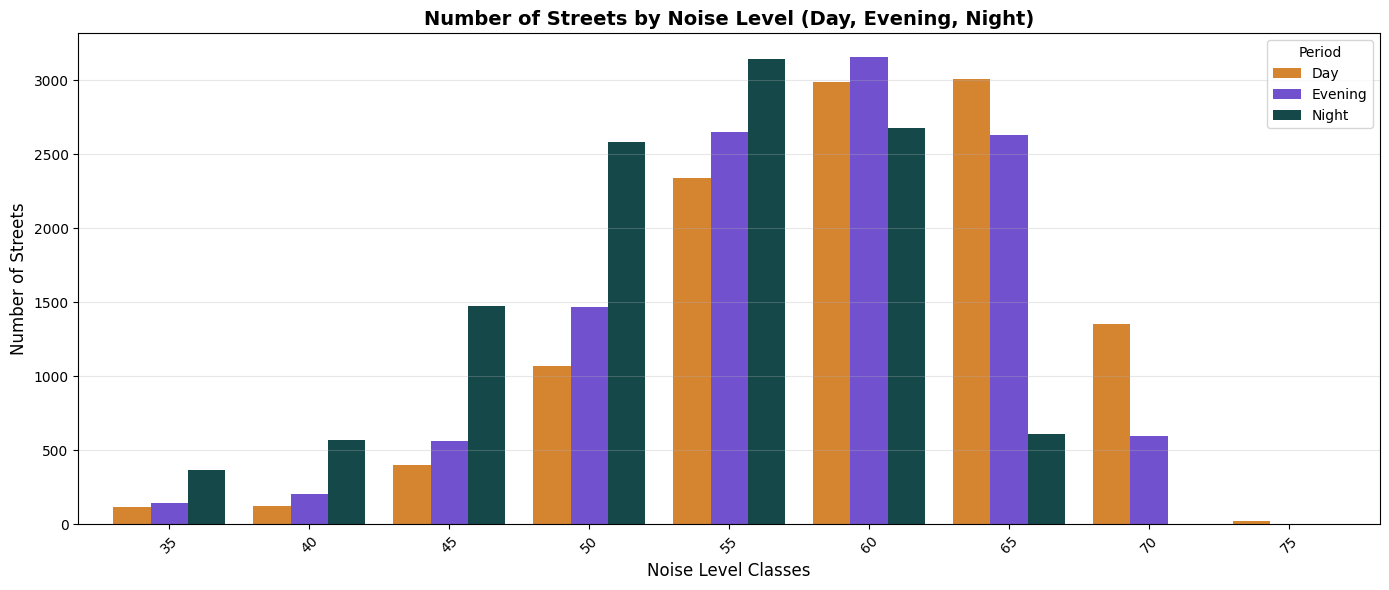

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
# Get counts for all three periods
counts_day = ml_dataset.groupby('noise_day').size()
counts_evening = ml_dataset.groupby('noise_evening').size()
counts_night = ml_dataset.groupby('noise_night').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Day': counts_day,
    'Evening': counts_evening,
    'Night': counts_night
})

print(comparison_df)
comparison_df[['Day', 'Evening', 'Night']].plot(kind='bar', ax=ax,width=0.8,color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Number of Streets by Noise Level (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level Classes', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export to CSV
Finally, we dump out the master table into a standard format readable by `scikit-learn` in the next phase!

In [10]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_regre_ml_dataset_with_tunnels.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_regre_ml_dataset_with_tunnels.csv


## Subsample

In [11]:
import pandas as pd

# Assume your DataFrame is called df and the noise column is 'noise_day'
# Set the desired sample size (e.g., 1000)
sample_size = 5000

# Calculate the proportion of each noise value in the original data
proportions = ml_dataset['noise_day'].value_counts(normalize=True).sort_index()

# Calculate how many samples to take for each noise value
samples_per_value = (proportions * sample_size).round().astype(int)

# Subsample for each noise value
subsampled = pd.concat([
    ml_dataset[ml_dataset['noise_day'] == val].sample(n=n, random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

# Shuffle the result
subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(subsampled['noise_day'].value_counts(normalize=True).sort_index())

noise_day
35    0.010402
40    0.010602
45    0.035007
50    0.093419
55    0.205041
60    0.261452
65    0.263453
70    0.118424
75    0.002200
Name: proportion, dtype: float64


## Before and after sampling

           Before  After
noise_day               
35            119     52
40            122     53
45            400    175
50           1068    467
55           2342   1025
60           2987   1307
65           3009   1317
70           1353    592
75             25     11


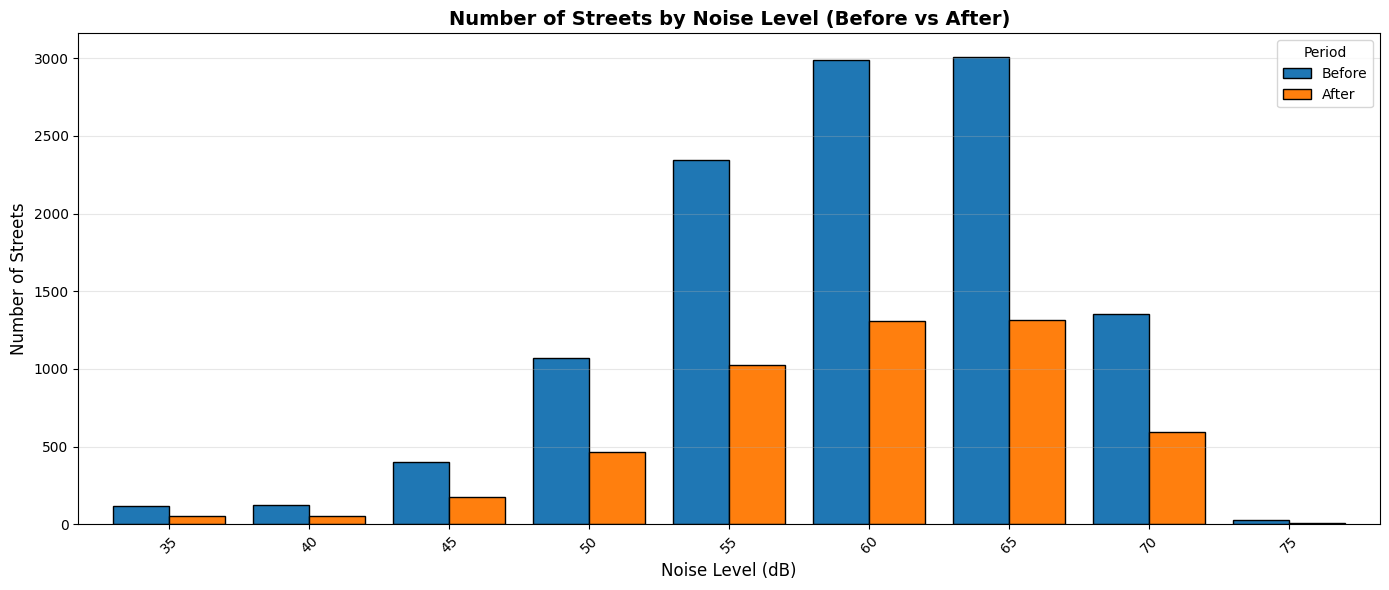

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
# Get counts for all three periods
counts_before = ml_dataset.groupby('noise_day').size()
counts_after = subsampled.groupby('noise_day').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Before': counts_before,
    'After': counts_after
})

print(comparison_df)
comparison_df[['Before', 'After']].plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export CSV

In [13]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "bcn_noise_regre_ml_subsample.csv")
subsampled.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\bcn_noise_regre_ml_subsample.csv
